# Bevel Edge Studio

Interactive editor for the raytraced 9-slice bevel tiles used by the site.

Every level (`panel`, `pill`, `image`) owns a corner radius and style, a height, a
skirt width, an edge profile, a material, and the material it rests on. The sun is a
Gaussian disc; the sky is a uniform dome integrated analytically per azimuth slice.

**The profile, curvature and normal panes are live** — they are pure spline
evaluations (~40 ms), so they redraw on every edit. The raytraced tile is ~700 ms, so
it sits below its own button: hit **Preview tile** when you want it, or tick **Auto
preview** to have it follow every change.

**Save config** writes `config.json`. **Reset to saved** discards edits. **Restore
defaults** loads the built-in values. **Render tiles** writes full-resolution PNGs to
`public/bevel/` and regenerates `src/bevel.generated.css`.

In [6]:
%matplotlib inline
from bevelkit.studio import launch

studio = launch()


## Profile library

All profiles map `u / skirt` (0 at the top rim, 1 where the skirt meets the page)
to `z / height`. `G3` profiles are C4 quintic splines whose first, second and third
derivatives vanish at the page, so the skirt melts into the background with no
curvature step. The rim at `u = 0` keeps a deliberate crease.

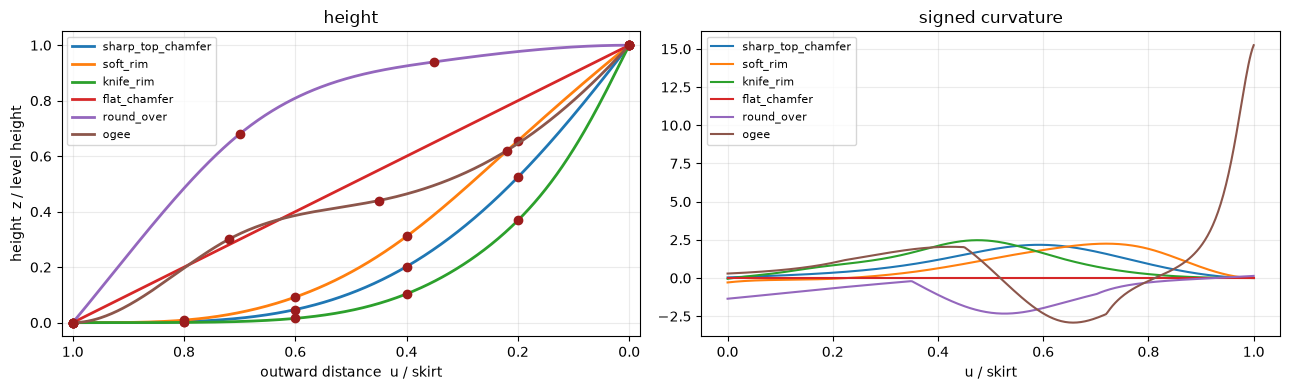

In [7]:
import matplotlib.pyplot as plt
import numpy as np

from bevelkit import EdgeProfile, load_config
from bevelkit.preview import compare_profiles

config = load_config()
figure, panes = plt.subplots(1, 2, figsize=(13, 4))
compare_profiles(config, axes=panes[0])
panes[0].set_title('height')

samples = np.linspace(0, 1, 400)
for name, spec in config['profiles'].items():
    panes[1].plot(samples, EdgeProfile.from_dict(spec).curvature(samples), label=name)
panes[1].set_title('signed curvature')
panes[1].set_xlabel('u / skirt')
panes[1].legend(fontsize=8)
panes[1].grid(alpha=0.25)
figure.tight_layout()


## Corner geometry

A CSS `border-radius` corner is a circular arc, so curvature jumps from `0` to `1/R`
at the tangent point — only G1. The `g3` corner instead ramps curvature smoothly
with `κ(s) ∝ sin²(πs/L)`, so `κ` and `dκ/ds` are both continuous at each end and the
straight sections stay *exactly* straight.

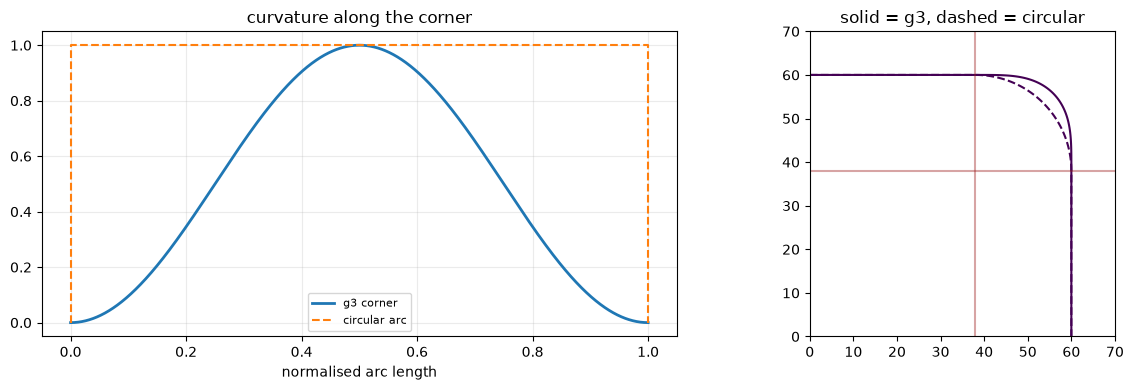

In [8]:
from bevelkit.corner import CircularCorner, ContinuousCorner, corner_curvature_profile

figure, panes = plt.subplots(1, 2, figsize=(13, 4))

t, curvature = corner_curvature_profile()
panes[0].plot(t, curvature, linewidth=2, label='g3 corner')
panes[0].plot([0, 0, 1, 1], [0, 1, 1, 0], '--', label='circular arc')
panes[0].set_title('curvature along the corner')
panes[0].set_xlabel('normalised arc length')
panes[0].legend(fontsize=8)
panes[0].grid(alpha=0.25)

extent = 22.0
half = 60.0
grid = np.linspace(0, half + 10, 700)
gx, gy = np.meshgrid(grid, grid)
for corner, style in ((ContinuousCorner(half, half, extent), '-'),
                      (CircularCorner(half, half, extent), '--')):
    panes[1].contour(gx, gy, corner.distance(gx, gy), levels=[0.0], linestyles=style)
panes[1].axvline(half - extent, color='#9c1c1c', alpha=0.4)
panes[1].axhline(half - extent, color='#9c1c1c', alpha=0.4)
panes[1].set_aspect('equal')
panes[1].set_title('solid = g3, dashed = circular')
figure.tight_layout()


## Nine-slice validity

The middle row and column of each tile get stretched across the whole element, so
they must be perfectly translation invariant. Anything non-zero here means the slice
inset is cutting into the corner and would smear corner shading down the straight
edges.

In [9]:
from PIL import Image

from bevelkit import TILE_DIR, level_names
from bevelkit.render import tile_metrics

for name in level_names(config):
    metrics = tile_metrics(config, name)
    inset = int(round(metrics['slice_css'] * config['render']['scale']))
    tile = np.asarray(Image.open(TILE_DIR / f'{name}.png')).astype(int)
    middle = tile[:, inset:tile.shape[1] - inset]
    rows = tile[inset:tile.shape[0] - inset, :]
    print(f"{name:6s} slice={inset:4d}px  column drift={np.abs(middle - middle[:, :1]).max()}"
          f"  row drift={np.abs(rows - rows[:1, :]).max()}")


panel  slice= 136px  column drift=0  row drift=0
pill   slice=  88px  column drift=0  row drift=0
image  slice=  66px  column drift=0  row drift=0


## Render everything

Equivalent to `python3 render_tiles.py` from `tools/bevel/`.

In [10]:
from bevelkit import write_tiles

write_tiles(load_config())


PosixPath('/Users/samb/Programming/web/portfolio/src/bevel.generated.css')